Inspired by: https://github.com/timqqt/FinRL-Library/blob/master/FinRL_portfolio_allocation_NeurIPS_2020.ipynb

<a id='1.1'></a>
## 1. Install all the packages through FinRL library


In [1]:
#!pip install -r requirements.txt

<a id='1.3'></a>
## 1. Import Packages

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from finrl import config
from finrl.agents.stablebaselines3.models import DRLAgent
import gym
from gym import spaces
from gym.utils import seeding
from stable_baselines3.common.vec_env import DummyVecEnv
from generators import UpwardTrendPriceGenerator, CashPriceGenerator
from environments import  StockPriceSimulator

In [3]:
# Define initial prices for stocks
initial_prices = {"UPWARD": 100, "CASH": 100}

# Define different price behaviors for each stock
generators = {
"UPWARD": UpwardTrendPriceGenerator(mean= 0.005, variance=0.09),  # Upward trend with N(0.1, 2) returns
    "CASH": CashPriceGenerator()  # Cash remains constant
}

# Create the simulator
simulator = StockPriceSimulator(days=500, initial_prices=initial_prices, generators=generators)

# Generate stock prices
train = simulator.generate_prices()

In [4]:
# Plot stock price
plt.figure(figsize=(12, 6))
for stock in train["tic"].unique():
    if stock != "CASH":
      stock_data = train[train["tic"] == stock]
      plt.plot(stock_data["date"], stock_data["close"], label=stock)

# Formatting the plot
plt.xlabel("Date")
plt.ylabel("Stock Price (Close)")
plt.title("Stock Price Trend")
plt.legend()
plt.grid(True)

# Save the plot as an image
plt.savefig("stock_price_trends.png")

In [5]:
train[['close', 'return_t-1', 'return_t-2', 'return_t-3', 'return_t-4', 'return_t-5']]

,close,return_t-1,return_t-2,return_t-3,return_t-4,return_t-5
0,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...
995,1657.192099,-0.112593,-0.175730,-0.185669,-0.254530,-0.213560
996,1810.278395,0.092377,-0.030617,-0.099587,-0.110443,-0.185666
997,2160.475077,0.193449,0.303696,0.156909,0.074597,0.061641
998,1914.501085,-0.113852,0.057573,0.155268,0.025193,-0.047748


In [6]:
# Filter rows where any column has `inf`
num_df = train[['close', 'return_t-1', 'return_t-2', 'return_t-3', 'return_t-4', 'return_t-5']]
inf_rows = num_df[np.isinf(num_df).any(axis=1)]
print("Rows containing `inf` values:\n", inf_rows)

Rows containing `inf` values:
 Empty DataFrame
Columns: [close, return_t-1, return_t-2, return_t-3, return_t-4, return_t-5]
Index: []


In [7]:
train.head()

,date,tic,close,return_t-1,return_t-2,return_t-3,return_t-4,return_t-5
0,2023-01-06,CASH,100.0,0.0,0.0,0.0,0.0,0.0
1,2023-01-07,CASH,100.0,0.0,0.0,0.0,0.0,0.0
2,2023-01-08,CASH,100.0,0.0,0.0,0.0,0.0,0.0
3,2023-01-09,CASH,100.0,0.0,0.0,0.0,0.0,0.0
4,2023-01-10,CASH,100.0,0.0,0.0,0.0,0.0,0.0


In [8]:
train.iloc[506:509]

,date,tic,close,return_t-1,return_t-2,return_t-3,return_t-4,return_t-5
506,2023-01-12,UPWARD,151.671590,-0.036042,0.017270,-0.019929,0.055420,0.222708
507,2023-01-13,UPWARD,146.174617,-0.036243,-0.070978,-0.019598,-0.055449,0.017169
508,2023-01-14,UPWARD,150.141551,0.027138,-0.010088,-0.045766,0.007008,-0.029815


In [9]:
train.loc[(train['tic'] == 'UPWARD') & (abs(train['return_t-1']) > 100)]


,date,tic,close,return_t-1,return_t-2,return_t-3,return_t-4,return_t-5


## Environment for Portfolio Allocation


In [10]:
pip install tabulate

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from tabulate import tabulate

class StockPortfolioEnv(gym.Env):
    """A single stock trading environment for OpenAI gym

    Attributes
    ----------
        df: DataFrame
            input data
        stock_dim : int
            number of unique stocks
        initial_amount : int
            start money
        transaction_cost_pct: float
            transaction cost percentage per trade
        reward_scaling: float
            scaling factor for reward, good for training
        state_space: int
            the dimension of input features
        action_space: int
            equals stock dimension
        past_returns: list
            list of past returns columns
        day: int
            an increment number to control date
        timestep_log: bool
            to display the Porfolio value, 

    Methods
    -------

    """
    metadata = {'render.modes': ['human']}
    
    def __init__(self,
                 df,
                 stock_dim,
                 initial_amount,
                 transaction_cost_pct,
                 reward_function="time_step_return",  # NEW: Selectable reward function
                 reward_scaling=1.0,
                 state_space=10,
                 action_space=10,
                 past_returns=None,
                 timestep_log=False,
                 day= -1):
        self.episode = -1  # Track episode number
        self.day = day
        self.df = df
        self.stock_dim = stock_dim
        self.initial_amount = initial_amount
        self.transaction_cost_pct = transaction_cost_pct
        self.reward_function = reward_function 
        self.reward_scaling = reward_scaling
        self.state_space = state_space
        self.action_space = action_space
        self.past_returns = past_returns
        self.timestep_log = timestep_log
        self.action_space = spaces.Box(low=0, high=1, shape=(self.action_space,))
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.state_space + len(self.past_returns), self.state_space))
      
        # Store logs in a DataFrame
        self.episode_log = []  # Will hold episode data

        self.data = self.df[self.df["date"] == self.df["date"].unique()[self.day]]
        self.state = self._get_state()  # Get state from our new helper
        self.terminal = False
        self.portfolio_value = self.initial_amount
        self.asset_memory = [self.initial_amount]
        self.portfolio_return_memory = [0]
        self.actions_memory = [[1 / self.stock_dim] * self.stock_dim]
 
        self.date_memory = [self.data.date.unique()[0]]

    def _get_state(self):
        # Sort by ticker for consistent ordering.
        data_sorted = self.data.sort_values("tic")
        state_columns = ["close"] + self.past_returns
        state_array = data_sorted[state_columns].to_numpy()
        return state_array.flatten()
           
    def softmax_normalization(self, actions):
        numerator = np.exp(actions)
        denominator = np.sum(np.exp(actions))
        softmax_output = numerator/denominator
        return softmax_output

    def step(self, actions):
        
        if self.day == -1:
            actions = [0.5, 0.5]

        weights = self.softmax_normalization(actions)
        
        if len(self.actions_memory) > 0:
            transaction_cost = self.transaction_cost_pct * np.sum(np.abs(weights - self.actions_memory[-1])) * self.portfolio_value
        else:
            transaction_cost = 0  # No cost on the first step
        
        # Append new allocation AFTER computing transaction cost
        self.actions_memory.append(weights)
        last_day_memory = self.data
        
        self.day += 1
        self.terminal = self.day >= len(self.df["date"].unique()) - 1
        self.data = self.df[self.df["date"] == self.df["date"].unique()[self.day]]
        self.state = self._get_state()
        
        # Compute individual stock returns
        stock_returns = self.data["return_t-1"].values
        # Compute portfolio return (weighted sum of stock returns)
        portfolio_return = sum(stock_returns * weights)

        # Update portfolio value
        new_portfolio_value = self.portfolio_value * (1 + portfolio_return) - transaction_cost
            # **Choose Reward Function**
        if self.reward_function == "sparse":
            if self.terminal:
                self.reward = new_portfolio_value - self.asset_memory[0] 
            else:
                self.reward = - transaction_cost
            
        elif self.reward_function == "dense":
            self.reward = new_portfolio_value - self.portfolio_value - transaction_cost
      
        else:
            raise ValueError("Invalid reward function. Choose 'final_portfolio_value' or 'time_step_return'.")

        
    
        if self.timestep_log == True:
            # Convert NumPy arrays to lists and format values
            table= [
                ["Episode", self.episode],
                ["Day", self.day],
                ["Actions (weights before softmax)", 
                ", ".join([f"{x:.2f}" for x in actions.tolist()]) if isinstance(actions, np.ndarray) else actions],
                ["Allocation weights", 
                ", ".join([f"{x:.2f}" for x in weights.tolist()]) if isinstance(weights, np.ndarray) else weights],
                ["Transaction Cost", f"{transaction_cost:.2f}"],
                ["Stock Returns", 
                ", ".join([f"{x:.2%}" for x in stock_returns.tolist()]) if isinstance(stock_returns, np.ndarray) else stock_returns],
                ["Portfolio Return", f"{portfolio_return:.2%}"],
                ["Reward", f"{self.reward:.2f}"],
                ["Old Portfolio Value", f"{self.portfolio_value:,.0f}"],  
                ["New Portfolio Value", f"{(self.portfolio_value * (1 + portfolio_return) - transaction_cost):,.0f}"]
            ]

            # Print a separator line before each table for better readability
            print("\n" + "=" * 53)  # Separator line
            print(tabulate(table, tablefmt="grid"))  # Print table without headers
            print("=" * 53 + "\n")  # Separator line after table

        # Store historical data
        self.portfolio_return_memory.append(portfolio_return)
        self.date_memory.append(self.data.date.unique()[0])
        self.asset_memory.append(new_portfolio_value)
        # print(f"Timestep: {self.day}")
        
        # **NEW: Store episode log with formatted values**
        self.episode_log.append({
            "episode": self.episode,
            "day": self.day,
            "actions": ", ".join([f"{x:.2f}" for x in actions.tolist()]) if isinstance(actions, np.ndarray) else actions,
            "allocation_weights": ", ".join([f"{x:.2f}" for x in weights.tolist()]) if isinstance(weights, np.ndarray) else weights,
            "transaction_cost": f"{transaction_cost:.2f}",
            "stock_returns": ", ".join([f"{x:.2%}" for x in stock_returns.tolist()]) if isinstance(stock_returns, np.ndarray) else stock_returns,
            "portfolio_return": f"{portfolio_return:.2%}",
            "reward": f"{self.reward:.2f}",
            "old_portfolio_value": f"{self.portfolio_value:,.0f}",
            "new_portfolio_value": f"{(self.portfolio_value * (1 + portfolio_return) - transaction_cost):,.0f}"
        })


        return self.state, self.reward, self.terminal, {}

    def reset(self):
        
        self.episode += 1  # Increment episode count
        print(f"\033[1;34mResetting environment for a new episode. Episode {self.episode} starting.\033[0m")
        self.asset_memory = [self.initial_amount]
        self.day = -1
        self.data = self.df[self.df["date"] == self.df["date"].unique()[self.day]]
        self.state = self._get_state()
        self.portfolio_value = self.initial_amount
        self.terminal = False
        self.portfolio_return_memory = [0]
        self.actions_memory = [[1 / self.stock_dim] * self.stock_dim]
        self.date_memory = [self.data.date.unique()[0]]
    
        return self.state

    def save_episode_log(self, filename="episode_log.csv"):
        """Save episode logs to a CSV file."""
        df_log = pd.DataFrame(self.episode_log)
        df_log.to_csv(filename, index=False)
        print(f"Saved episode log to {filename}")


    def _seed(self, seed=None):
        self.np_random, seed = seeding.np_random(seed)
        return [seed]

    def get_sb_env(self):
        e = DummyVecEnv([lambda: self])
        obs = e.reset()
        print("EPISODE: ", self.episode)
        return e, obs

In [30]:
# from tabulate import tabulate

# class StockPortfolioEnv(gym.Env):
#     """A single stock trading environment for OpenAI gym

#     Attributes
#     ----------
#         df: DataFrame
#             input data
#         stock_dim : int
#             number of unique stocks
#         initial_amount : int
#             start money
#         transaction_cost_pct: float
#             transaction cost percentage per trade
#         reward_scaling: float
#             scaling factor for reward, good for training
#         state_space: int
#             the dimension of input features
#         action_space: int
#             equals stock dimension
#         past_returns: list
#             list of past returns columns
#         day: int
#             an increment number to control date
#         timestep_log: bool
#             to display the Porfolio value, 

#     Methods
#     -------

#     """
#     metadata = {'render.modes': ['human']}
    
#     def __init__(self,
#                  df,
#                  stock_dim,
#                  initial_amount,
#                  transaction_cost_pct,
#                  reward_function="time_step_return",  # NEW: Selectable reward function
#                  reward_scaling=1.0,
#                  state_space=10,
#                  action_space=10,
#                  past_returns=None,
#                  timestep_log=False,
#                  day= -1):
#         self.episode = -1  # Track episode number
#         self.day = day
#         self.df = df
#         self.stock_dim = stock_dim
#         self.initial_amount = initial_amount
#         self.transaction_cost_pct = transaction_cost_pct
#         self.reward_function = reward_function 
#         self.reward_scaling = reward_scaling
#         self.state_space = state_space
#         self.action_space = action_space
#         self.past_returns = past_returns
#         self.timestep_log = timestep_log
#         self.action_space = spaces.Box(low=0, high=1, shape=(self.action_space,))
#         self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.state_space + len(self.past_returns), self.state_space))
      
#         # Store logs in a DataFrame
#         self.episode_log = []  # Will hold episode data

#         self.data = self.df[self.df["date"] == self.df["date"].unique()[self.day]]
#         self.state = self._get_state()  # Get state from our new helper
#         self.terminal = False
#         self.portfolio_value = self.initial_amount
#         self.asset_memory = [self.initial_amount]
#         self.portfolio_return_memory = [0]
#         self.actions_memory = [[1 / self.stock_dim] * self.stock_dim]
 
#         self.date_memory = [self.data.date.unique()[0]]

#     def _get_state(self):
#         # Sort by ticker for consistent ordering.
#         data_sorted = self.data.sort_values("tic")
#         state_columns = ["close"] + self.past_returns
#         state_array = data_sorted[state_columns].to_numpy()
#         return state_array.flatten()
           
#     def softmax_normalization(self, actions):
#         numerator = np.exp(actions)
#         denominator = np.sum(np.exp(actions))
#         softmax_output = numerator/denominator
#         return softmax_output

#     def step(self, actions):
#         self.terminal = self.day >= len(self.df["date"].unique()) - 1

#         if self.terminal:
#                     df = pd.DataFrame(self.portfolio_return_memory)
#                     df.columns = ['daily_return']
                    

#                     print("\033[1;33m=================================\033[0m")  # Yellow
#                     print("Episode {} Summary".format(self.episode-1))
#                     print("begin_total_asset:{}".format(self.asset_memory[0]))
#                     print("end_total_asset:{}".format(self.portfolio_value))

#                     df_daily_return = pd.DataFrame(self.portfolio_return_memory)
#                     df_daily_return.columns = ['daily_return']
#                     if df_daily_return['daily_return'].std() !=0:
#                       sharpe = (252**0.5)*df_daily_return['daily_return'].mean()/ \
#                               df_daily_return['daily_return'].std()
#                       print("Sharpe: ",sharpe)
#                     print("\033[1;33m=================================\033[0m\n\n")  # Yellow
#                     print("Reward", self.reward)
#                     return self.state, self.reward, self.terminal,{}

#         else:
#             if self.day == -1:
#                 actions = [0.5, 0.5]

#             weights = self.softmax_normalization(actions)
            
#             if len(self.actions_memory) > 0:
#                 transaction_cost = self.transaction_cost_pct * np.sum(np.abs(weights - self.actions_memory[-1])) * self.portfolio_value
#             else:
#                 transaction_cost = 0  # No cost on the first step
          
#             # Append new allocation AFTER computing transaction cost
#             self.actions_memory.append(weights)
#             last_day_memory = self.data
          
#             self.day += 1
  
#             self.data = self.df[self.df["date"] == self.df["date"].unique()[self.day]]
#             self.state = self._get_state()
            
#             # Compute individual stock returns
#             stock_returns = self.data["return_t-1"].values
#             # Compute portfolio return (weighted sum of stock returns)
#             portfolio_return = sum(stock_returns * weights)

#             # Update portfolio value
#             new_portfolio_value = self.portfolio_value * (1 + portfolio_return) - transaction_cost
#              # **Choose Reward Function**
#             if self.reward_function == "sparse":
#                 if self.day >= len(self.df["date"].unique()) - 1:
#                     self.reward = new_portfolio_value - self.asset_memory[0] 
#                 else:
#                     self.reward = - transaction_cost
#             elif self.reward_function == "dense":
#                 self.reward = new_portfolio_value - self.portfolio_value - transaction_cost
#             else:
#                 raise ValueError("Invalid reward function. Choose 'final_portfolio_value' or 'time_step_return'.")

#             self.portfolio_value = max(1e-6, new_portfolio_value)  # Prevent zero or negative values
     
#             if self.timestep_log == True:
#                 # Convert NumPy arrays to lists and format values
#                 table= [
#                     ["Episode", self.episode],
#                     ["Day", self.day],
#                     ["Actions (weights before softmax)", 
#                     ", ".join([f"{x:.2f}" for x in actions.tolist()]) if isinstance(actions, np.ndarray) else actions],
#                     ["Allocation weights", 
#                     ", ".join([f"{x:.2f}" for x in weights.tolist()]) if isinstance(weights, np.ndarray) else weights],
#                     ["Transaction Cost", f"{transaction_cost:.2f}"],
#                     ["Stock Returns", 
#                     ", ".join([f"{x:.2%}" for x in stock_returns.tolist()]) if isinstance(stock_returns, np.ndarray) else stock_returns],
#                     ["Portfolio Return", f"{portfolio_return:.2%}"],
#                     ["Reward", f"{self.reward:.2f}"],
#                     ["Old Portfolio Value", f"{self.portfolio_value:,.0f}"],  
#                     ["New Portfolio Value", f"{(self.portfolio_value * (1 + portfolio_return) - transaction_cost):,.0f}"]
#                 ]

#                 # Print a separator line before each table for better readability
#                 print("\n" + "=" * 53)  # Separator line
#                 print(tabulate(table, tablefmt="grid"))  # Print table without headers
#                 print("=" * 53 + "\n")  # Separator line after table

#             # Store historical data
#             self.portfolio_return_memory.append(portfolio_return)
#             self.date_memory.append(self.data.date.unique()[0])
#             self.asset_memory.append(new_portfolio_value)
#             # print(f"Timestep: {self.day}")
           
#              # **NEW: Store episode log**
#             self.episode_log.append({
#                 "episode": self.episode,
#                 "day": self.day,
#                 "portfolio_value": self.portfolio_value,
#                 "portfolio_return": portfolio_return,
#                 "reward": self.reward,
#                 "transaction_cost": transaction_cost,
#                 "allocation":weights
#             })

#         return self.state, self.reward, self.terminal, {}

#     def reset(self):
        
#         self.episode += 1  # Increment episode count
#         print(f"\033[1;34mResetting environment for a new episode. Episode {self.episode} starting.\033[0m")
#         self.asset_memory = [self.initial_amount]
#         self.day = -1
#         self.data = self.df[self.df["date"] == self.df["date"].unique()[self.day]]
#         self.state = self._get_state()
#         self.portfolio_value = self.initial_amount
#         self.terminal = False
#         self.portfolio_return_memory = [0]
#         self.actions_memory = [[1 / self.stock_dim] * self.stock_dim]
#         self.date_memory = [self.data.date.unique()[0]]
    
#         return self.state

#     def save_episode_log(self, filename="episode_log.csv"):
#         """Save episode logs to a CSV file."""
#         df_log = pd.DataFrame(self.episode_log)
#         df_log.to_csv(filename, index=False)
#         print(f"Saved episode log to {filename}")


#     def _seed(self, seed=None):
#         self.np_random, seed = seeding.np_random(seed)
#         return [seed]

#     def get_sb_env(self):
#         e = DummyVecEnv([lambda: self])
#         obs = e.reset()
#         print("EPISODE: ", self.episode)
#         return e, obs

In [31]:
train.iloc[499]

date          2024-05-19 00:00:00
tic                          CASH
close                       100.0
return_t-1                    0.0
return_t-2                    0.0
return_t-3                    0.0
return_t-4                    0.0
return_t-5                    0.0
Name: 499, dtype: object

In [32]:
(124.045595/126.055404)-1

-0.015943854338842822

In [33]:
train.iloc[500:502]

,date,tic,close,return_t-1,return_t-2,return_t-3,return_t-4,return_t-5
500,2023-01-06,UPWARD,126.055404,-0.015945,0.134281,0.208392,0.199431,0.260554
501,2023-01-07,UPWARD,124.045595,-0.015944,-0.031635,0.116196,0.189126,0.180307


In [34]:
train.iloc[0:2]

,date,tic,close,return_t-1,return_t-2,return_t-3,return_t-4,return_t-5
0,2023-01-06,CASH,100.0,0.0,0.0,0.0,0.0,0.0
1,2023-01-07,CASH,100.0,0.0,0.0,0.0,0.0,0.0


In [35]:
stock_dimension = len(train.tic.unique())
state_space = stock_dimension
print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")


Stock Dimension: 2, State Space: 2


In [36]:
stock_dimension = len(train["tic"].unique())  # Count unique stocks
state_space = len(["close", "return_t-1", "return_t-2", "return_t-3", "return_t-4", "return_t-5"]) * stock_dimension

env_kwargs = {
    "initial_amount": 100,
    "transaction_cost_pct": 0.01,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "past_returns": ["return_t-1", "return_t-2", "return_t-3", "return_t-4", "return_t-5"],
    "action_space": stock_dimension,
    "reward_scaling": 1,
     "reward_function": "sparse",
     "timestep_log":True
}

# Create the environment
e_train_gym = StockPortfolioEnv(df=train, **env_kwargs)


In [37]:
env_train, _ = e_train_gym.get_sb_env()
print(type(env_train))

Resetting environment for a new episode. Episode 0 starting.
EPISODE:  0
<class 'stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv'>


/opt/anaconda3/envs/rl_project/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [38]:
# initialize
agent = DRLAgent(env = env_train)
DDPG_PARAMS = {"batch_size": 128, "buffer_size": 50000, "learning_rate": 0.001}
model_ddpg = agent.get_model("ddpg",model_kwargs = DDPG_PARAMS)

{'batch_size': 128, 'buffer_size': 50000, 'learning_rate': 0.001}
Using cpu device


In [39]:
train

,date,tic,close,return_t-1,return_t-2,return_t-3,return_t-4,return_t-5
0,2023-01-06,CASH,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2023-01-07,CASH,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2023-01-08,CASH,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2023-01-09,CASH,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2023-01-10,CASH,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...
995,2024-05-15,UPWARD,1657.192099,-0.112593,-0.175730,-0.185669,-0.254530,-0.213560
996,2024-05-16,UPWARD,1810.278395,0.092377,-0.030617,-0.099587,-0.110443,-0.185666
997,2024-05-17,UPWARD,2160.475077,0.193449,0.303696,0.156909,0.074597,0.061641
998,2024-05-18,UPWARD,1914.501085,-0.113852,0.057573,0.155268,0.025193,-0.047748


In [40]:
episodes = 5
days = 501
trained_ddpg = agent.train_model(model=model_ddpg,tb_log_name='ddpg',total_timesteps=episodes*days)

Resetting environment for a new episode. Episode 1 starting.

+----------------------------------+---------------+
| Episode                          | 1             |
+----------------------------------+---------------+
| Day                              | 0             |
+----------------------------------+---------------+
| Actions (weights before softmax) | [0.5, 0.5]    |
+----------------------------------+---------------+
| Allocation weights               | 0.50, 0.50    |
+----------------------------------+---------------+
| Transaction Cost                 | 0.00          |
+----------------------------------+---------------+
| Stock Returns                    | 0.00%, -1.59% |
+----------------------------------+---------------+
| Portfolio Return                 | -0.80%        |
+----------------------------------+---------------+
| Reward                           | -0.00         |
+----------------------------------+---------------+
| Old Portfolio Value              | 

In [23]:
e_train_gym.save_episode_log("training_logs.csv")

Saved episode log to training_logs.csv


In [24]:
import pandas as pd

df_logs = pd.read_csv("training_logs.csv")
print(df_logs.head())

   episode  day  portfolio_value  portfolio_return    reward  \
0        1    0              100         -0.007973 -0.000000   
1        1    1              100         -0.009787 -0.227653   
2        1    2              100          0.099601 -0.029111   
3        1    3              100          0.025437 -0.595046   
4        1    4              100         -0.018408 -0.345076   

   transaction_cost               allocation  
0          0.000000                [0.5 0.5]  
1          0.227653    [0.3861735 0.6138265]  
2          0.029111    [0.3716178 0.6283822]  
3          0.595046    [0.6691408 0.3308592]  
4          0.345076  [0.49660274 0.5033973 ]  


In [25]:
df_logs['episode'].unique()

array([1, 2, 3, 4, 5, 6])

In [26]:
df_logs

,episode,day,portfolio_value,portfolio_return,reward,transaction_cost,allocation
0,1,0,100,-0.007973,-0.000000,0.000000,[0.5 0.5]
1,1,1,100,-0.009787,-0.227653,0.227653,[0.3861735 0.6138265]
2,1,2,100,0.099601,-0.029111,0.029111,[0.3716178 0.6283822]
3,1,3,100,0.025437,-0.595046,0.595046,[0.6691408 0.3308592]
4,1,4,100,-0.018408,-0.345076,0.345076,[0.49660274 0.5033973 ]
...,...,...,...,...,...,...,...
2495,6,0,100,-0.007973,-0.000000,0.000000,[0.5 0.5]
2496,6,1,100,-0.004288,-0.462117,0.462117,[0.7310586 0.26894143]
2497,6,2,100,0.042628,-0.000000,0.000000,[0.7310586 0.26894143]
2498,6,3,100,0.020677,-0.000000,0.000000,[0.7310586 0.26894143]


In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df_logs = pd.read_csv("training_logs.csv")

# Get unique episodes
episodes = df_logs["episode"].unique()
num_episodes = len(episodes)  # Total number of episodes

# Define function to plot `n` graphs
def plot_per_episode(df, metric, ylabel, title, filename):
    """Plot separate time series for each episode of a given metric."""
    fig, axes = plt.subplots(num_episodes, 1, figsize=(10, 4 * num_episodes), sharex=True)

    if num_episodes == 1:
        axes = [axes]  # Ensure axes is iterable for a single episode

    for idx, episode in enumerate(episodes):
        df_episode = df[df["episode"] == episode]
        axes[idx].plot(df_episode["day"], df_episode[metric], label=f"Episode {episode}", color="b")
        axes[idx].set_ylabel(ylabel)
        axes[idx].legend()
        axes[idx].set_title(f"{title} - Episode {episode}")

    plt.xlabel("Day")
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()  # Close figure to prevent excessive memory usage

# **1️⃣ Save Portfolio Value Plot**
plot_per_episode(df_logs, "portfolio_value", "Portfolio Value ($)", "Portfolio Value Time Series", "portfolio_value.png")

# **2️⃣ Save Portfolio Return Plot**
plot_per_episode(df_logs, "portfolio_return", "Portfolio Return (%)", "Portfolio Return Time Series", "portfolio_return.png")

# **3️⃣ Save Reward Plot**
plot_per_episode(df_logs, "reward", "Reward", "Reward Time Series", "reward.png")

# **4️⃣ Save Transaction Cost Plot**
plot_per_episode(df_logs, "transaction_cost", "Transaction Cost ($)", "Transaction Cost Time Series", "transaction_cost.png")

print("Plots saved as images.")




Plots saved as images.


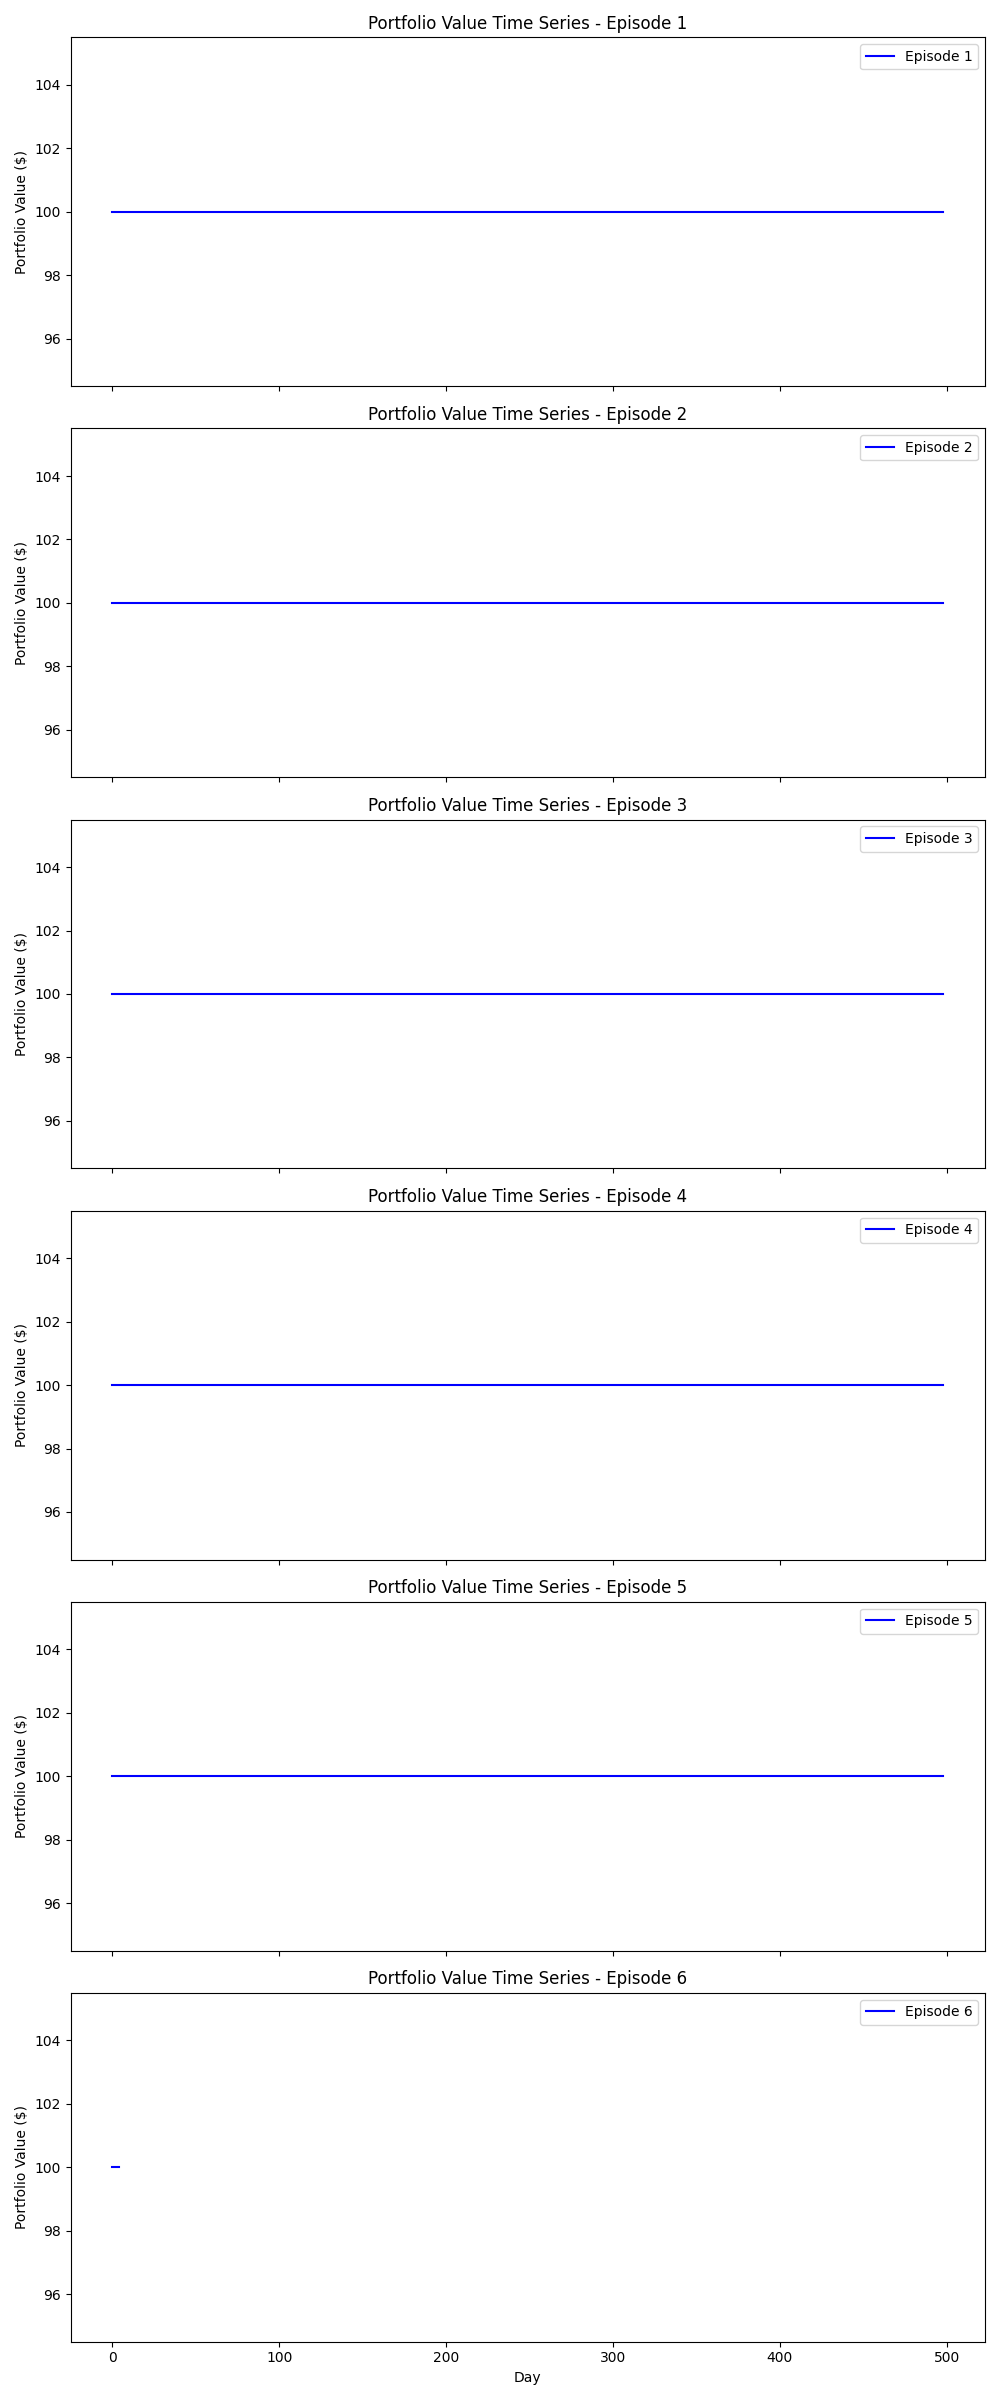

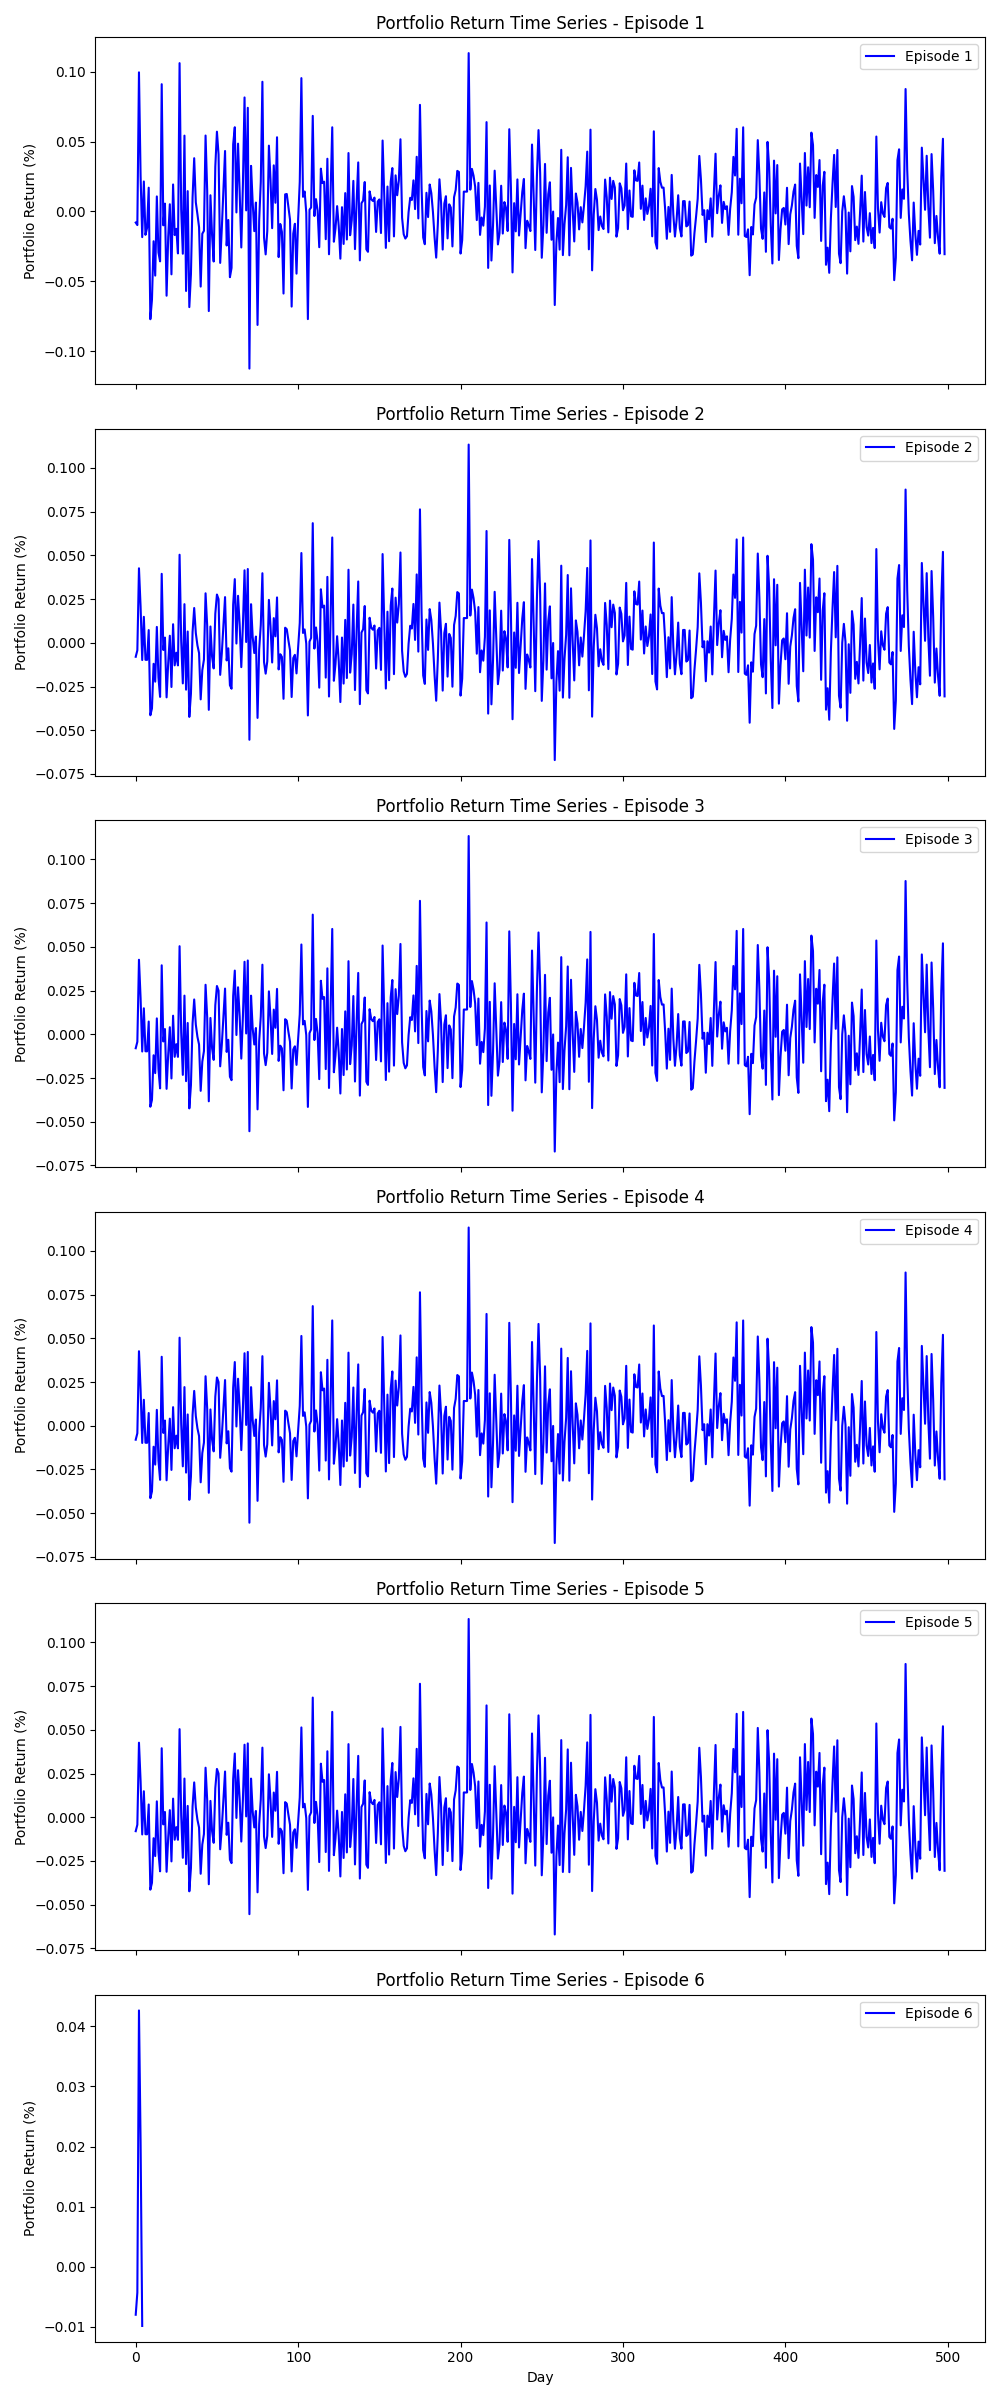

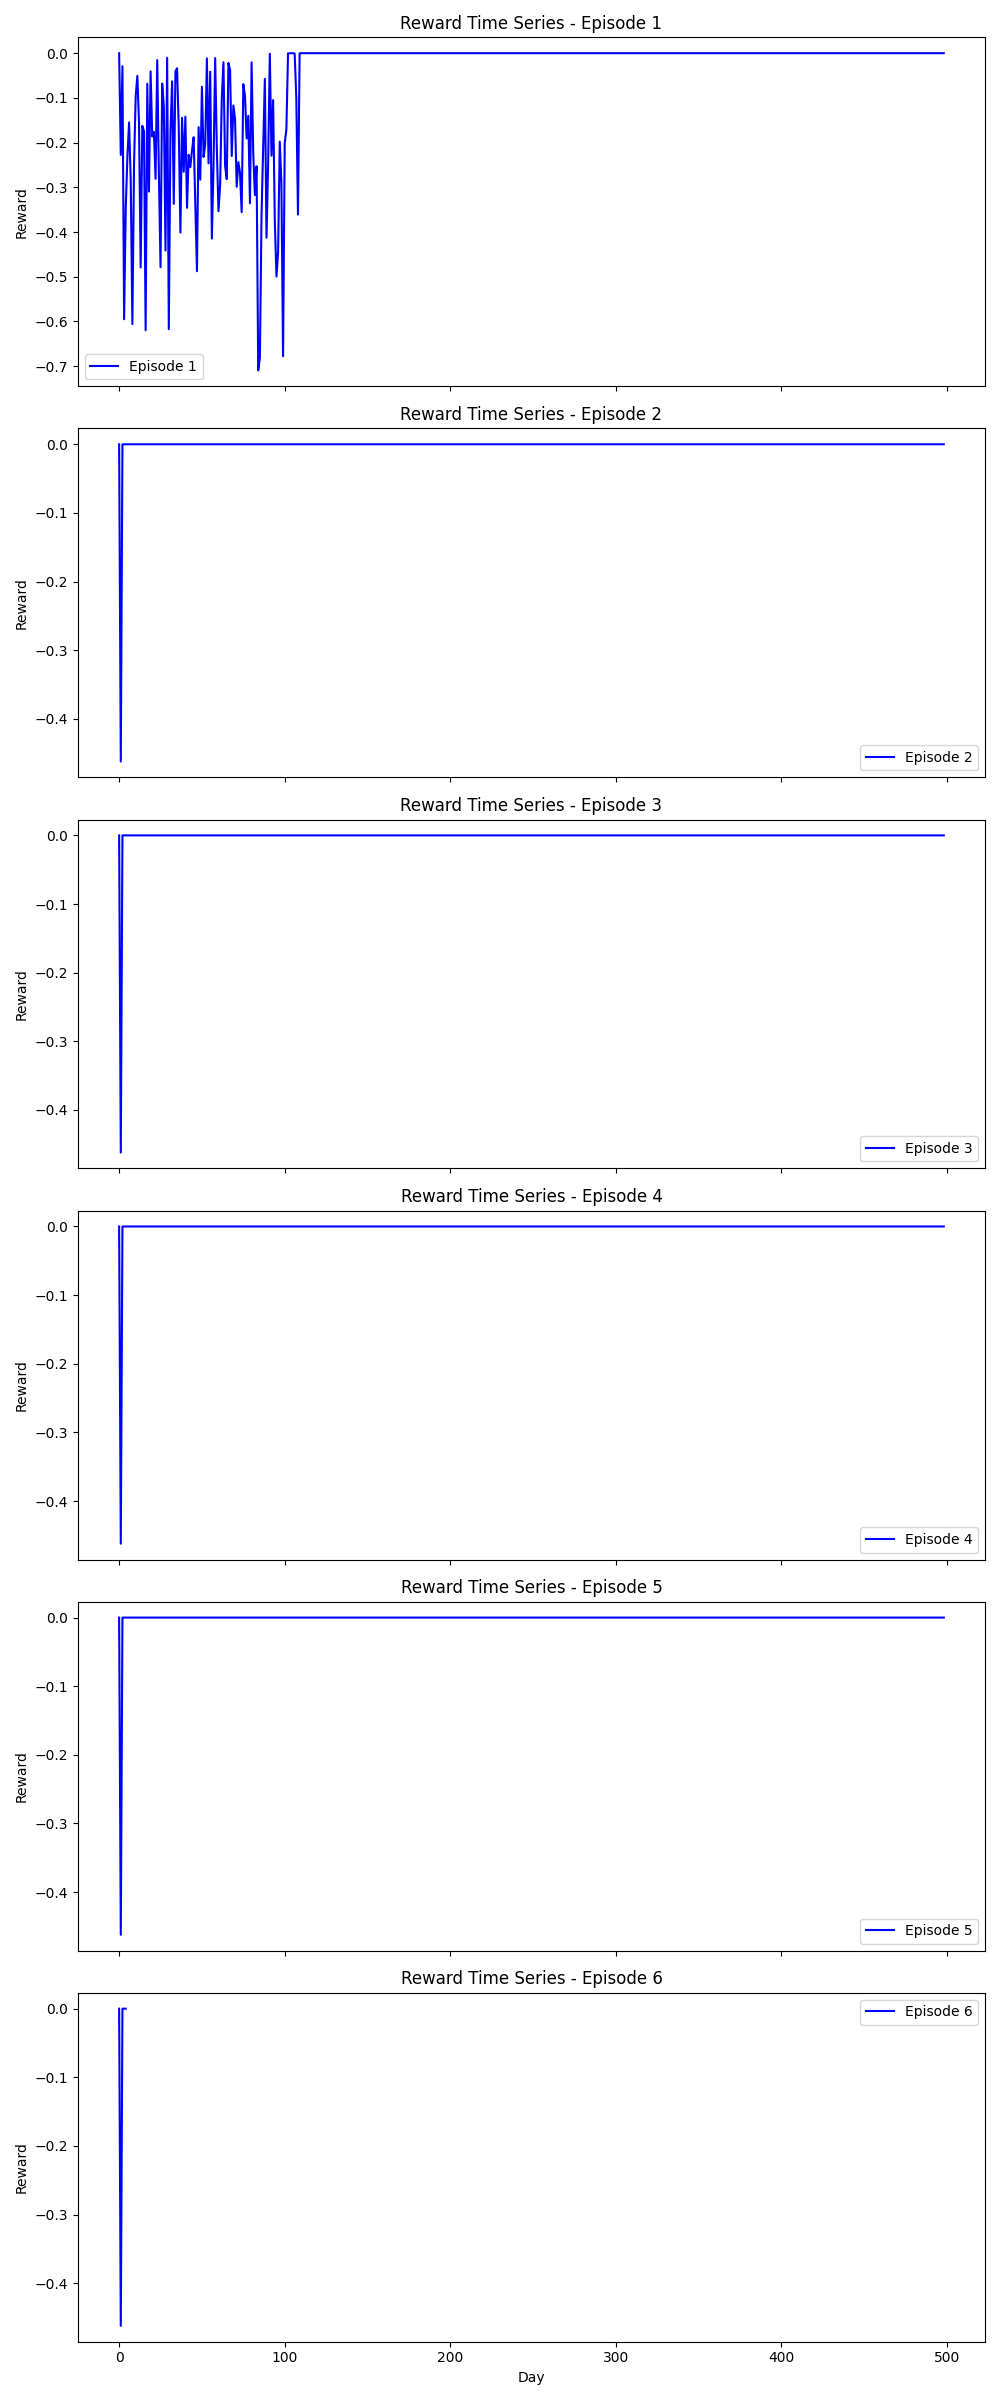

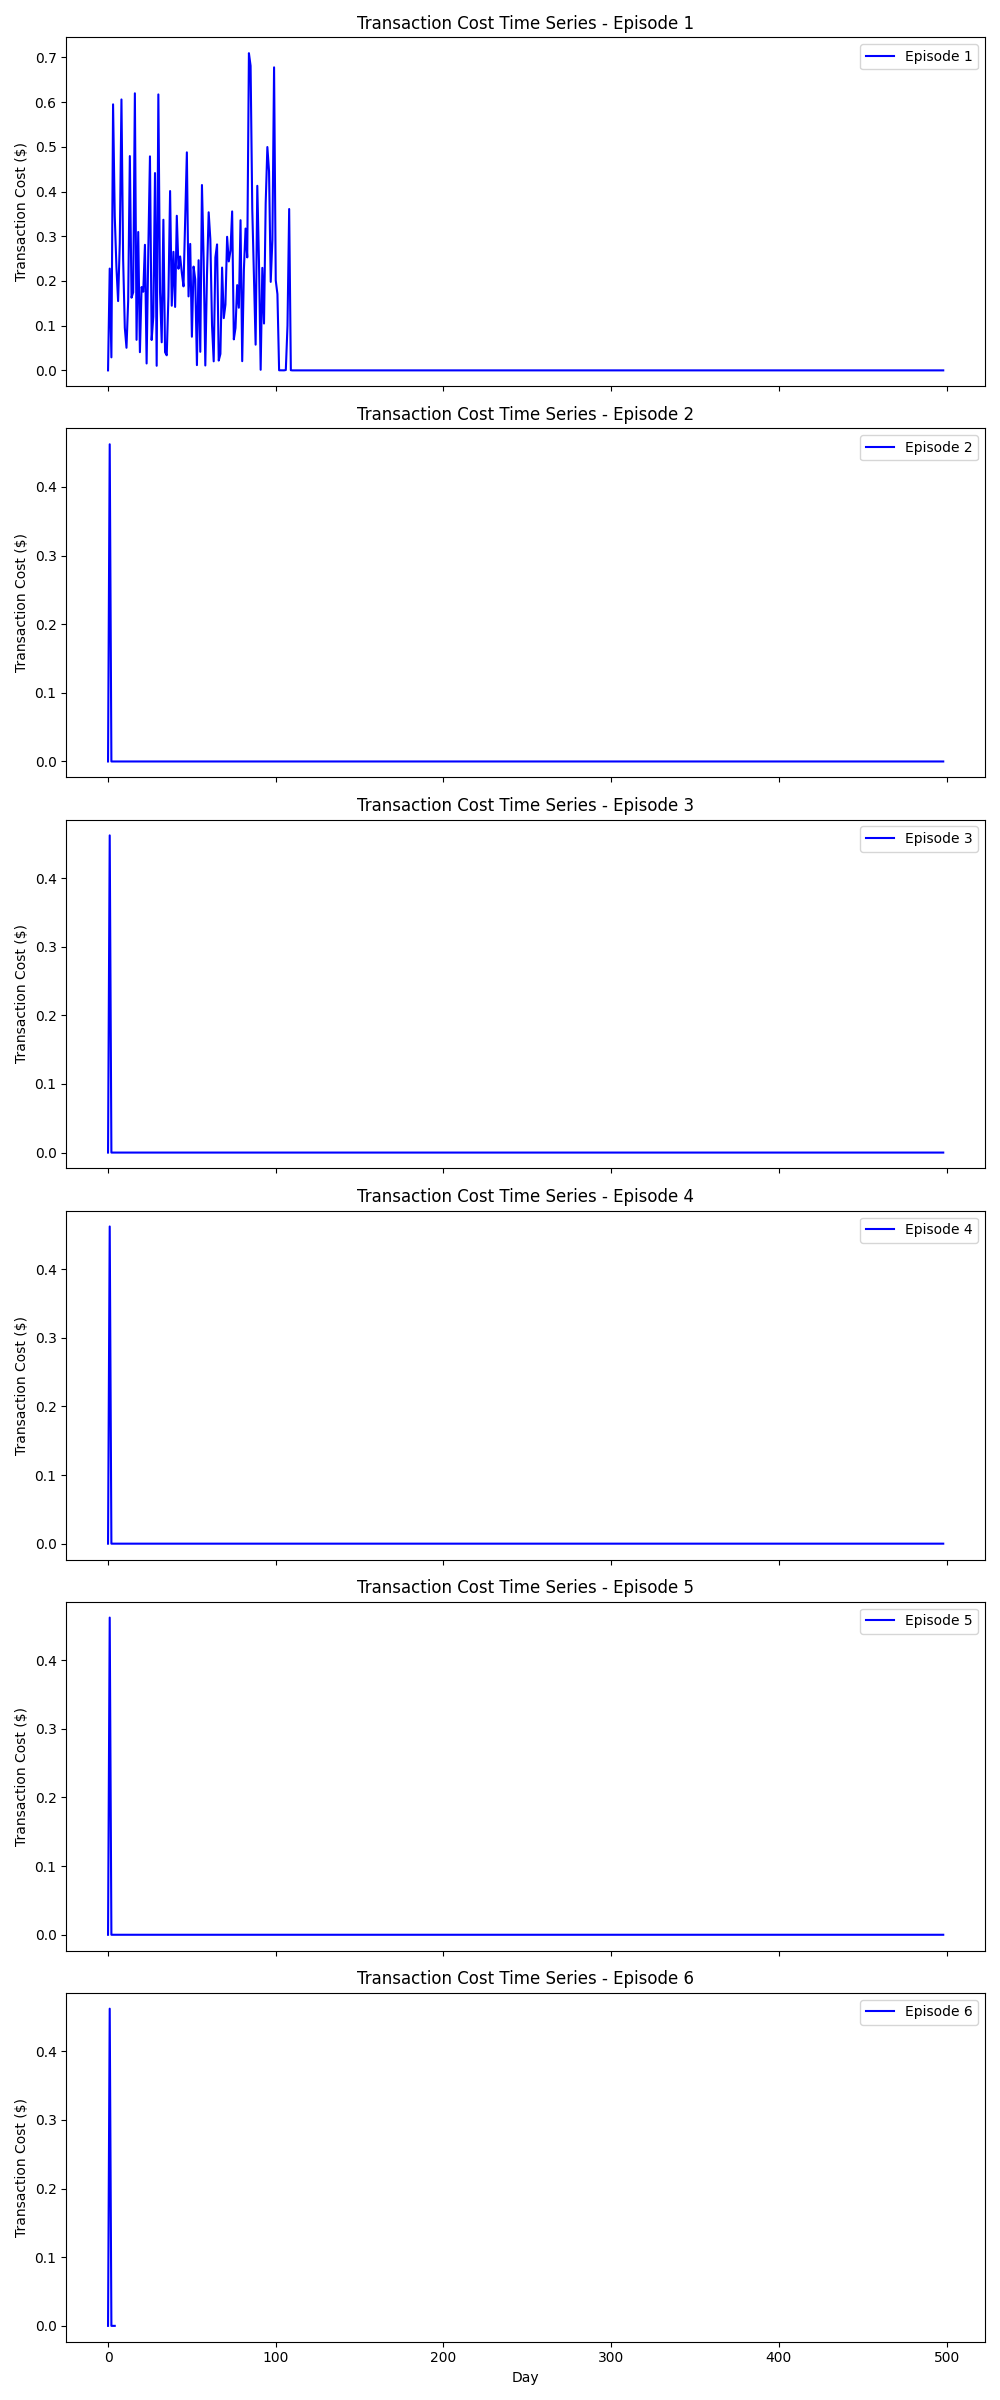

In [28]:
from IPython.display import display
from PIL import Image

display(Image.open("portfolio_value.png"))
display(Image.open("portfolio_return.png"))
display(Image.open("reward.png"))
display(Image.open("transaction_cost.png"))
